In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec

import os

import seaborn as sns


In [5]:
## Downloaded CR-arc count matrix results
data_dir = '/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/downloaded_counts/VIB_10xmultiome_2'

## Entropy filtered atac
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'

# Load peak annotations [including peak AUC score from Genrich peaks]
union_cells_dir = os.path.join(entropy_dir, '_cell_calling_comparison')
peaks_annot = pd.read_csv(os.path.join(union_cells_dir, 'Rawpeaks/annotation', 'annotated_peaks.bed'),      sep='\t')
entropy_peaks_annot = pd.read_csv(os.path.join(union_cells_dir, 'Entropy_cells_peaks/annotation/', 'annotated_peaks.bed'), sep='\t')
lost_peaks_annot = pd.read_csv(os.path.join(union_cells_dir, 'Entropypeaks_vs_Rawpeaks/annotation/' 'annotated_lost_peaks.bed'), sep='\t')
newly_discovered_peaks_annot = pd.read_csv(os.path.join(union_cells_dir, 'Entropypeaks_vs_Rawpeaks/annotation', 'annotated_newly_discovered_peaks.bed'),  sep='\t')


In [6]:

## calcualte peak size
newly_discovered_peaks_annot['peak_size'] = newly_discovered_peaks_annot['End'] - newly_discovered_peaks_annot['Start']
lost_peaks_annot['peak_size'] = lost_peaks_annot['End'] - lost_peaks_annot['Start']

peaks_annot['peak_size'] = peaks_annot['End'] - peaks_annot['Start']
entropy_peaks_annot['peak_size'] = entropy_peaks_annot['End'] - entropy_peaks_annot['Start']

## Peak AUC score 

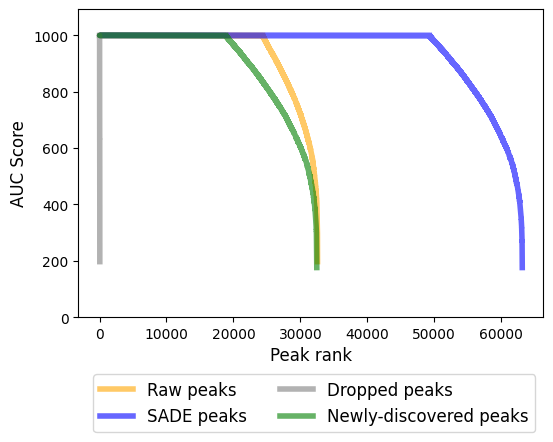

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(peaks_annot['Peak Score'].sort_values(ascending=False), '-', color='orange', alpha=0.6, label='Raw peaks', lw=4)
ax.plot(entropy_peaks_annot['Peak Score'].sort_values(ascending=False), '-', color='blue', alpha=0.6, label='SADE peaks', lw=4)
ax.plot(lost_peaks_annot['Peak Score'].sort_values(ascending=False), '-', color='gray', alpha=0.6, label='Dropped peaks', lw=4)
ax.plot(newly_discovered_peaks_annot['Peak Score'].sort_values(ascending=False), '-', color='green', alpha=0.6, label='Newly-discovered peaks', lw=4)
# ax.set_title('Peak Score Comparison', fontsize=12)
ax.set_xlabel('Peak rank', fontsize=12)
ax.set_ylabel('AUC Score', fontsize=12)
ax.set_ylim(0, ax.get_ylim()[1]*1.05)
ax.legend( loc='lower right', bbox_to_anchor=(1, -0.4), fontsize=12, ncol=2)

--- 	 Raw
peaks , SADE
Peaks , Dropped
Peaks Newly-discovered
Peaks
Mean [np.float64(945.7244872896966), np.float64(949.1592970790786), np.float64(709.4878048780488), np.float64(901.7805366439728)]
Median [np.float64(1000.0), np.float64(1000.0), np.float64(705.0), np.float64(1000.0)]


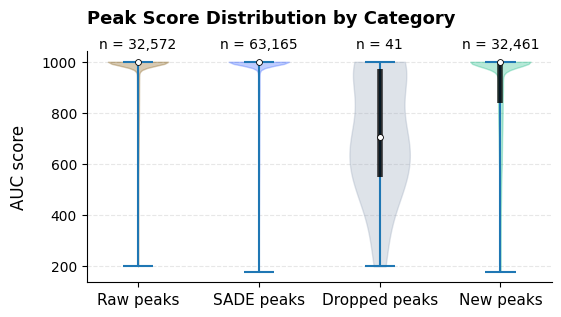

In [8]:
fig, ax = plt.subplots(figsize=(6, 3))
x_positions = range(4)
width = 0.5 


peaks_score = [
                peaks_annot['Peak Score'],
                entropy_peaks_annot['Peak Score'],
                lost_peaks_annot['Peak Score'],
                newly_discovered_peaks_annot['Peak Score'],
]
x_positions = range(len(peaks_score))
labels = ['Raw peaks', 'SADE peaks', 'Dropped peaks', 'New peaks']

v = ax.violinplot( peaks_score, positions=x_positions, widths=width, vert=True)

n_peaks = [len(a) for a in peaks_score]
for i, n in zip(x_positions, n_peaks):
    ax.text(i, ax.get_ylim()[1]*1.01, f'n = {n:,}', ha='center', fontsize=10)

# 3. Customize Bodies and Add Interior Stats
colors = ["#7D520675", '#2E5BFF', '#94A3B8', '#10B981']
for i, body in enumerate(v['bodies']):
    body.set_facecolor(colors[i])
    body.set_edgecolor(colors[i])
    body.set_alpha(0.3)
    body.set_zorder(2)
    
    # Calculate stats for the "Inner Boxplot"
    data = peaks_score[i]
    q1, median, q3 = np.percentile(data, [25, 50, 75])
    mean_val = np.mean(data)

    # Draw thick line for the IQR
    ax.vlines(i, q1, q3, color='black', lw=4, alpha=0.8)
    # Draw the Median as a white dot
    ax.scatter(i, median, color='white', s=18, zorder=4, edgecolor='black', lw=0.6)

# 4. Clean up Axes and Labels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.3, zorder=0)

ax.set_xticks(range(4))
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('AUC score', fontsize=12, labelpad=10)
ax.set_title('Peak Score Distribution by Category', fontsize=13, fontweight='bold', loc='left', pad=20)



auc_score = [
             peaks_annot['Peak Score'], 
             entropy_peaks_annot['Peak Score'], 
             lost_peaks_annot['Peak Score'], 
             newly_discovered_peaks_annot['Peak Score'], 
             ]
mean_score = [np.mean(a) for a in auc_score]
median_score = [np.median(a) for a in auc_score]
print ('--- \t Raw\npeaks , SADE\nPeaks , Dropped\nPeaks', 'Newly-discovered\nPeaks')
print (f'Mean {mean_score}')
print (f'Median {median_score}')


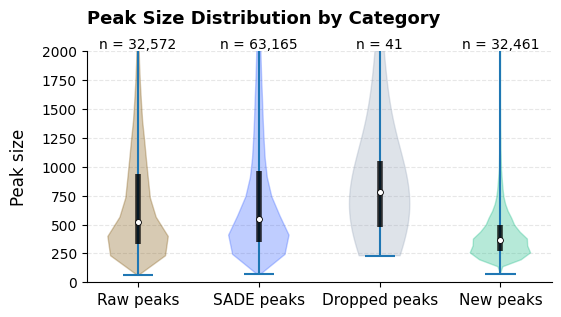

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3))
x_positions = range(4)
width = 0.5 


peaks_size = [
                peaks_annot['peak_size'],
                entropy_peaks_annot['peak_size'],
                lost_peaks_annot['peak_size'],
                newly_discovered_peaks_annot['peak_size'],
]
x_positions = range(len(peaks_size))
labels = ['Raw peaks', 'SADE peaks', 'Dropped peaks', 'New peaks']

v = ax.violinplot( peaks_size, positions=x_positions, widths=width, vert=True)


colors = ["#7D520675", '#2E5BFF', '#94A3B8', '#10B981']
for i, body in enumerate(v['bodies']):
    body.set_facecolor(colors[i])
    body.set_edgecolor(colors[i])
    body.set_alpha(0.3)
    body.set_zorder(2)
    
    # Calculate stats for the "Inner Boxplot"
    data = peaks_size[i]
    q1, median, q3 = np.percentile(data, [25, 50, 75])
    mean_val = np.mean(data)

    # Draw thick line for the IQR
    ax.vlines(i, q1, q3, color='black', lw=4, alpha=0.8)
    # Draw the Median as a white dot
    ax.scatter(i, median, color='white', s=18, zorder=4, edgecolor='black', lw=0.6)

#  Clean up Axes and Labels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.3, zorder=0)

ax.set_xticks(range(4))
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Peak size', fontsize=12, labelpad=10)
ax.set_title('Peak Size Distribution by Category', fontsize=13, fontweight='bold', loc='left', pad=20)
ax.set_ylim(0, 2000)

n_peaks = [len(a) for a in peaks_size]
for i, n in zip(x_positions, n_peaks):
    ax.text(i, ax.get_ylim()[1]*1.01, f'n = {n:,}', ha='center', fontsize=10)



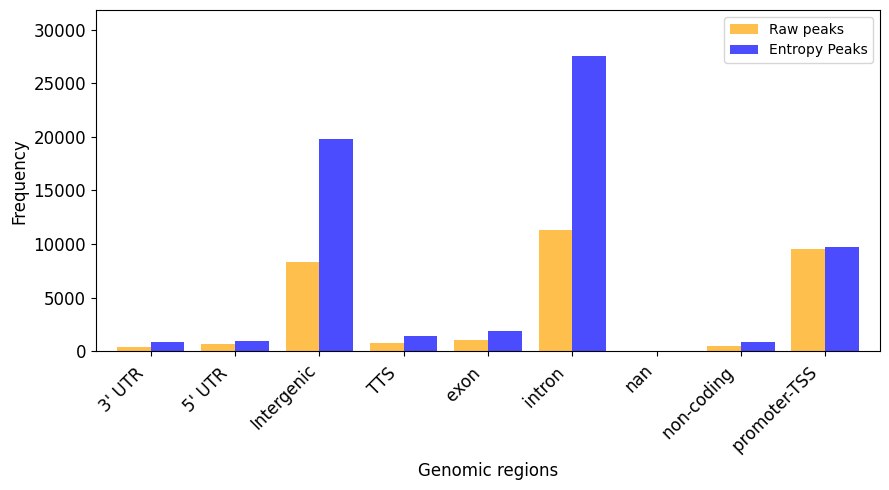

In [10]:
def simplify_annotation(annot_df, inplace=False):
    """
    Simplify the Annotation column.
    """
    if not inplace:
        annot_df = annot_df.copy()
        annot_df['simple_annotation'] = annot_df['Annotation'].apply(lambda x: str(x).split('(')[0])  
        return annot_df
    else:
        # in place change of the  DataFrame
        annot_df['simple_annotation'] = annot_df['Annotation'].apply(lambda x: str(x).split('(')[0])  
        
simplify_annotation(peaks_annot, inplace=True)
simplify_annotation(entropy_peaks_annot, inplace=True)
simplify_annotation(lost_peaks_annot, inplace=True)
simplify_annotation(newly_discovered_peaks_annot, inplace=True)

        
standard_peak_freq = peaks_annot['simple_annotation'].value_counts()
entropy_peak_freq = entropy_peaks_annot['simple_annotation'].value_counts()
newly_discovered_peak_freq = newly_discovered_peaks_annot['simple_annotation'].value_counts()
lost_standard_peak_freq = lost_peaks_annot['simple_annotation'].value_counts()

freq_df = pd.DataFrame({
    'Raw peaks': standard_peak_freq,
    'Entropy Peaks': entropy_peak_freq
}).fillna(0)

fig, ax = plt.subplots(figsize=(9, 5))
freq_df.plot(kind='bar', width=0.8, alpha=0.7, ax=ax, color=['orange', 'blue'], fontsize=12)



# ax.set_title('Peak Annotation Frequency Comparison', fontsize=12)
ax.set_ylim( 0, ax.get_ylim()[1]*1.1)
ax.set_xlabel('Genomic regions', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_ylabel('Frequency', fontsize=12)
ax.legend()
fig.tight_layout()

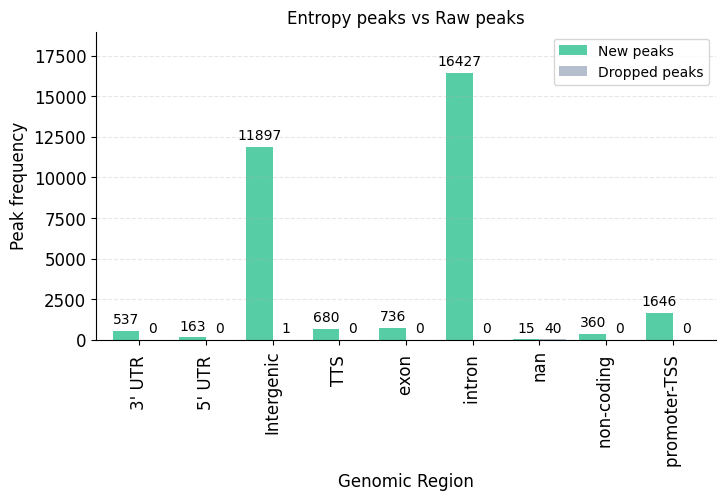

In [11]:
color_map = {'intron ': 'blue', 'promoter-TSS ': 'orange', 'Intergenic': 'green', 'exon ': 'red',
                "5' UTR ": 'purple', 'TTS ': 'brown', 'non-coding ': 'pink', "3' UTR ": 'slateblue', 'nan': 'grey'}
index_map = {'intron ': 0, 'promoter-TSS ': 1, 'Intergenic': 2, 'exon ': 3,
                "5' UTR ": 4, 'TTS ': 5, 'non-coding ': 6, "3' UTR ": 7, 'nan': 8}

width = 0.3  # the width of the bars
fig, ax = plt.subplots( nrows=1, ncols=1, figsize=(8,4))

a=newly_discovered_peak_freq.to_frame().merge(
    lost_standard_peak_freq.to_frame(), left_index=True, right_index=True, how='outer', suffixes=('_newly_discovered', '_dropped')).fillna(0)
a.rename(columns={'count_newly_discovered': 'New peaks', 'count_dropped': 'Dropped peaks'}, inplace=True)
a.plot(kind='bar', width=0.8, alpha=0.7, ax=ax, color=[  '#10B981', '#94A3B8'], fontsize=12)


for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.3, zorder=0)

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylim( 0, ax.get_ylim()[1]*1.1)
ax.set_ylabel('Peak frequency', fontsize=12)
ax.set_xlabel('Genomic Region', fontsize=12) 
ax.legend(loc='upper right', ncols=1, bbox_to_anchor=(1, 1))
ax.set_title('Entropy peaks vs Raw peaks')

plt.show()

In [18]:
newly_discovered_peaks_annot.groupby('simple_annotation').size() / newly_discovered_peaks_annot.shape[0]

simple_annotation
3' UTR           0.016543
5' UTR           0.005021
Intergenic       0.366501
TTS              0.020948
exon             0.022673
intron           0.506053
nan              0.000462
non-coding       0.011090
promoter-TSS     0.050707
dtype: float64

/tmp/ipykernel_213178/344636915.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=lost_peaks_annot, x='peak_size', hue='simple_annotation', fill=True, ax=ax[1],


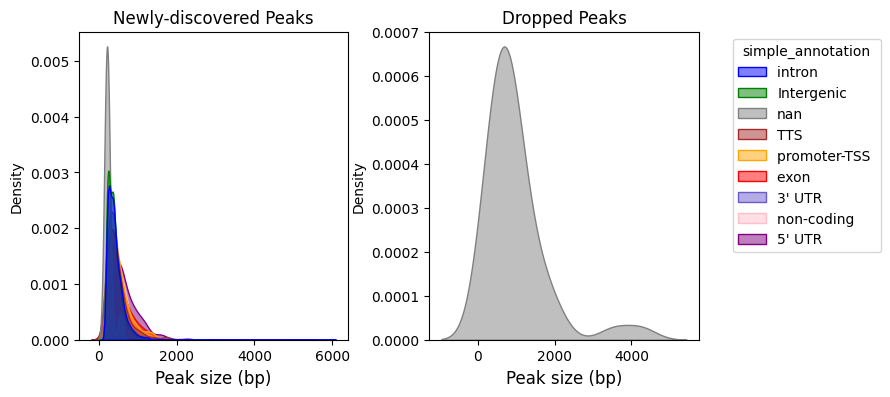

In [25]:
color_map = {'intron ': 'blue', 'promoter-TSS ': 'orange', 'Intergenic': 'green', 'exon ': 'red',
                "5' UTR ": 'purple', 'TTS ': 'brown', 'non-coding ': 'pink', "3' UTR ": 'slateblue', 'nan': 'grey'}
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

sns.kdeplot(data=newly_discovered_peaks_annot, x='peak_size', hue='simple_annotation', fill=True, ax=ax[0], 
            common_norm=False, alpha=0.5, palette=color_map)
sns.kdeplot(data=lost_peaks_annot, x='peak_size', hue='simple_annotation', fill=True, ax=ax[1], 
            common_norm=False, alpha=0.5, palette=color_map)

ax[0].set_xlabel('Peak size (bp)', fontsize=12)
ax[0].set_title('Newly-discovered Peaks', fontsize=12)
ax[1].set_xlabel('Peak size (bp)', fontsize=12)
ax[1].set_title('Dropped Peaks', fontsize=12)


ax[1].legend_.remove()
sns.move_legend(ax[0], "upper right", bbox_to_anchor=(3, 1))

fig.subplots_adjust(wspace=0.3)

-------------- 	 Raw peaks , Entropy peaks , Newly-discovered peaks , Dropped peaks
Median peak size: ['526.0         ', '545.0         ', '366.0         ', '783.0         ']
Mean peak size: [np.float64(694.4691759793687), np.float64(772.7578880709253), np.float64(418.7236067896861), np.float64(959.5365853658536)]


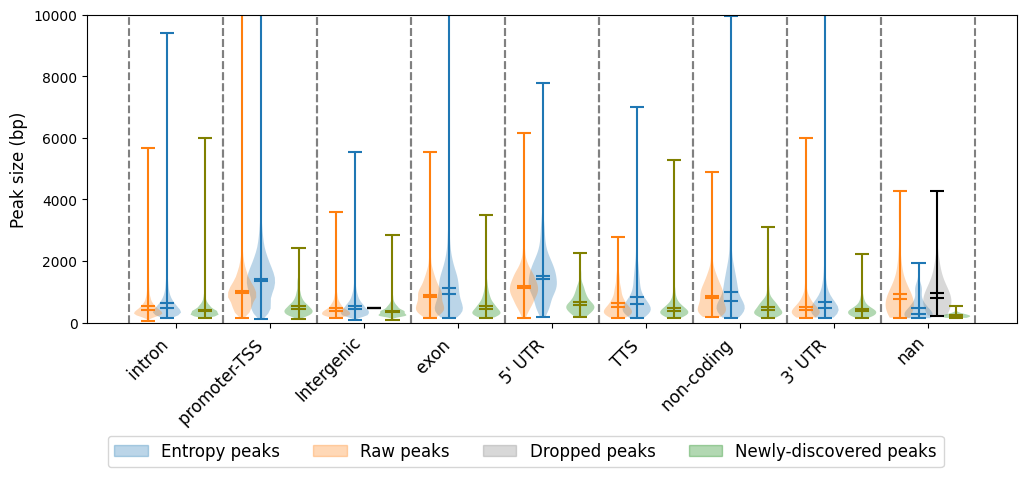

In [20]:
from matplotlib.pylab import size


position_map = {'intron ': 0, 'promoter-TSS ': 1, 'Intergenic': 2, 'exon ': 3,
                "5' UTR ": 4, 'TTS ': 5, 'non-coding ': 6, "3' UTR ": 7, 'nan': 8}

position_map_reversed = {v: k for k, v in position_map.items()}


def add_label(violin, label):
    color = violin["bodies"][0].get_facecolor().flatten()
    labels.append((mpatches.Patch(color=color), label))
    

x_positions = range(len(position_map)) 
width = 0.3  # the width of the bars
labels = []

fig, ax = plt.subplots( figsize=(12, 4))

standard_type = peaks_annot['simple_annotation'].unique()
entropy_type = entropy_peaks_annot['simple_annotation'].unique()
newly_discovered_type = newly_discovered_peaks_annot['simple_annotation'].unique()
lost_type = lost_peaks_annot['simple_annotation'].unique()

standard_peak_size = [ peaks_annot.loc[peaks_annot['simple_annotation'] == genome_type, 'peak_size'] for \
    genome_type in standard_type ]

entropy_peak_size = [ entropy_peaks_annot.loc[entropy_peaks_annot['simple_annotation'] == genome_type, 'peak_size'] for \
    genome_type in entropy_type ]
newly_discovered_peak_size = [ newly_discovered_peaks_annot.loc[newly_discovered_peaks_annot['simple_annotation'] == genome_type, 'peak_size'] for \
    genome_type in newly_discovered_type     ]  
lost_peak_size = [ lost_peaks_annot.loc[lost_peaks_annot['simple_annotation'] == genome_type, 'peak_size'] for \
    genome_type in lost_type ]


v2 =ax.violinplot( entropy_peak_size, 
              positions=[position_map[genome_type] - 0.1 for genome_type in entropy_type], widths=width, vert=True, 
              showmedians=True, showmeans=True,)
add_label(v2, 'Entropy peaks')

v1 = ax.violinplot( standard_peak_size, 
              positions=[position_map[genome_type] - 0.3 for genome_type in standard_type], widths=width, vert=True, 
              showmedians=True, showmeans=True,)
add_label(v1, 'Raw peaks')


v3 = ax.violinplot( lost_peak_size, 
              positions=[position_map[genome_type] + 0.1 for genome_type in lost_type], widths=width, vert=True, 
              showmedians=True, showmeans=True,)
# change color 
for body in v3['bodies']:
    body.set_facecolor( 'grey'   )
for partname in ('cbars','cmins','cmaxes','cmeans','cmedians'):
    v3[partname].set_edgecolor('black')
add_label(v3, 'Dropped peaks')


v4 =ax.violinplot( newly_discovered_peak_size, 
              positions=[position_map[genome_type] + 0.3 for genome_type in newly_discovered_type], widths=width, vert=True, 
              showmedians=True, showmeans=True,)
# change color
for body in v4['bodies']:
    body.set_facecolor('green')
for partname in ('cbars','cmins','cmaxes','cmeans','cmedians'):
    v4[partname].set_edgecolor('olive')

add_label(v4, 'Newly-discovered peaks')


## Add vertical line to separate each group
for x in x_positions:
    ax.vlines(x + 0.5 , ymin=0, ymax=20000, colors='grey', linestyles='--')
    ax.vlines(x - 0.5 , ymin=0, ymax=20000, colors='grey', linestyles='--')


ax.set_xticks(x_positions)
ax.set_xticklabels([position_map_reversed[i] for i in x_positions], rotation=45, ha='right', fontsize=12)
ax.set_ylim(0, 10000)
ax.set_ylabel('Peak size (bp)', fontsize=12)
plt.legend(*zip(*labels), loc='upper right', bbox_to_anchor=(0.93, -0.34), ncol=4, fontsize=12)

median_peak_size = [np.median(peaks_annot['peak_size']), np.median(entropy_peaks_annot['peak_size']),
                    np.median(newly_discovered_peaks_annot['peak_size']), np.median(lost_peaks_annot['peak_size'])]
mean_peak_size = [np.mean(peaks_annot['peak_size']), np.mean(entropy_peaks_annot['peak_size']),
                    np.mean(newly_discovered_peaks_annot['peak_size']), np.mean(lost_peaks_annot['peak_size'])]
print(f'-------------- \t Raw peaks , Entropy peaks , Newly-discovered peaks , Dropped peaks')
print(f'Median peak size: {[str(size) + "         " for size in median_peak_size]}') # show with 4 decimal places
print(f'Mean peak size: {mean_peak_size}')




In [21]:
newly_discovered_peaks_annot

,PeakID (cmd=annotatePeaks.pl /mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/_cell_calling_comparison/Entropypeaks_vs_Rawpeaks/newly_discovered_peaks.bed hg38 -annStats /mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/_cell_calling_comparison/Entropypeaks_vs_Rawpeaks/annotation/annStats_newly_discovered_peaks.txt),Chr,Start,End,Strand,Peak Score,Focus Ratio/Region Size,Annotation,Detailed Annotation,Distance to TSS,...,Entrez ID,Nearest Unigene,Nearest Refseq,Nearest Ensembl,Gene Name,Gene Alias,Gene Description,Gene Type,peak_size,simple_annotation
0,peak_11911,chr11,113019788,113020090,+,1000,NaN,"intron (NM_001076682, intron 1 of 18)","intron (NM_001076682, intron 1 of 18)",-56479.0,...,101928847.0,NaN,NR_120563,ENSG00000247416,LOC101928847,-,uncharacterized LOC101928847,ncRNA,302,intron
1,peak_45564,chr4,39699771,39699990,+,1000,NaN,"intron (NM_001111113, intron 1 of 4)","intron (NM_001111113, intron 1 of 4)",1744.0,...,3093.0,NaN,NM_005339,ENSG00000078140,UBE2K,E2-25K|HIP2|HYPG|LIG|UBC1,ubiquitin conjugating enzyme E2 K,protein-coding,219,intron
2,peak_22987,chr16,58097304,58097504,+,1000,NaN,Intergenic,Intergenic,31977.0,...,29105.0,NaN,NM_013242,ENSG00000070761,CFAP20,BUG22|C16orf80|EVORF|GTL3|fSAP23,cilia and flagella associated protein 20,protein-coding,200,Intergenic
3,peak_16859,chr13,95204443,95204656,+,1000,NaN,"intron (NM_001301830, intron 7 of 19)",THE1D|LTR|ERVL-MaLR,-5795.0,...,109616987.0,NaN,NR_145733,NaN,SNORD13G,-,"small nucleolar RNA, C/D box 13G",snoRNA,213,intron
4,peak_50804,chr6,21856890,21857358,+,1000,NaN,"intron (NR_015410, intron 4 of 11)",MLT1E3|LTR|ERVL-MaLR,190711.0,...,401237.0,NaN,NR_015410,NaN,CASC15,CANT|LINC00340|lnc-SOX4-1,cancer susceptibility 15,ncRNA,468,intron
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32456,peak_14202,chr12,57220536,57221882,+,206,NaN,"intron (NM_007224, intron 1 of 1)","intron (NM_007224, intron 1 of 1)",4415.0,...,11247.0,NaN,NM_007224,ENSG00000182379,NXPH4,NPH4,neurexophilin 4,protein-coding,1346,intron
32457,peak_49955,chr5,177449824,177451260,+,199,NaN,"intron (NM_001174102, intron 1 of 2)","intron (NM_001174102, intron 1 of 2)",2217.0,...,80758.0,NaN,NM_030567,ENSG00000131188,PRR7,-,"proline rich 7, synaptic",protein-coding,1436,intron
32458,peak_53968,chr7,1543335,1544341,+,199,NaN,TTS (NM_002360),TTS (NM_002360),-8958.0,...,100128653.0,NaN,NR_149036,NaN,LOC100128653,-,uncharacterized LOC100128653,ncRNA,1006,TTS
32459,peak_30763,chr19,39415899,39417454,+,185,NaN,"intron (NM_022835, intron 6 of 18)","intron (NM_022835, intron 6 of 18)",2897.0,...,64857.0,NaN,NM_022835,ENSG00000090924,PLEKHG2,ARHGEF42|CLG|CTB-60E11.4|LDAMD,pleckstrin homology and RhoGEF domain containi...,protein-coding,1555,intron


# Check cCRE annotations

In [26]:
cCRE_subdir=os.path.join(union_cells_dir,'Entropypeaks_vs_Rawpeaks/' 'cCRE_annotation')
cCRE_newly_discovered_peaks_file = os.path.join(cCRE_subdir, 'cCRE_annot_newly_discovered_peaks.bed')
cCRE_lost_peaks_file = os.path.join(cCRE_subdir, 'cCRE_annot_lost_peaks.bed')

cCRE_newly_discovered_peaks = pd.read_csv(cCRE_newly_discovered_peaks_file, sep='\t', header=None)
cCRE_lost_peaks = pd.read_csv(cCRE_lost_peaks_file, sep='\t', header=None)

columns = ['chrom', 'chromStart', 'chromEnd', 'name', 'peak_auc_score', 'strand', 'signalValue', 'pValue', 'qValue', 'peak', 
           'cCREs_chrom', 'cCREs_start', 'cCREs_end', 'cCREs_an1', 'cCREs_an2', 'encode_label', 'overlap_bp']

cCRE_lost_peaks.columns = columns
cCRE_newly_discovered_peaks.columns = columns

cCRE_lost_peaks.shape, cCRE_newly_discovered_peaks.shape,

((41, 17), (46857, 17))

In [27]:
cCRE_newly_discovered_peaks.head(2)

,chrom,chromStart,chromEnd,name,peak_auc_score,strand,signalValue,pValue,qValue,peak,cCREs_chrom,cCREs_start,cCREs_end,cCREs_an1,cCREs_an2,encode_label,overlap_bp
0,chr1,906614,907191,peak_11,1000,.,617.520630,5.286901,-1,279,chr1,906736,907074,EH38D4327697,EH38E2776603,"dELS,CTCF-bound",338
1,chr1,921009,921525,peak_12,1000,.,614.844727,5.056138,-1,261,chr1,921184,921360,EH38D4327731,EH38E2776632,"pELS,CTCF-bound",176


In [28]:
cCRE_lost_peaks.head(6)

,chrom,chromStart,chromEnd,name,peak_auc_score,strand,signalValue,pValue,qValue,peak,cCREs_chrom,cCREs_start,cCREs_end,cCREs_an1,cCREs_an2,encode_label,overlap_bp
0,chr1,144104205,144104694,peak_1780,548,.,267.775543,3.103723,-1,443,.,-1,-1,.,.,.,0
1,KI270442.1,391172,392051,peak_32786,542,.,476.026672,3.399083,-1,234,.,-1,-1,.,.,.,0
2,KI270729.1,1155,1849,peak_32787,1000,.,771.622559,4.155765,-1,386,.,-1,-1,.,.,.,0
3,KI270729.1,2175,3710,peak_32788,1000,.,3725.948242,5.831364,-1,959,.,-1,-1,.,.,.,0
4,KI270729.1,4062,5209,peak_32789,1000,.,1956.790161,5.308810,-1,781,.,-1,-1,.,.,.,0
5,KI270729.1,5514,5973,peak_32790,438,.,201.109619,3.336699,-1,381,.,-1,-1,.,.,.,0


In [29]:
# total lost peaks that cover CREs 
len(cCRE_lost_peaks.loc[cCRE_lost_peaks['overlap_bp'] > 0 ]['name'].unique()) 

0

In [30]:
# Total CREs newly-discovered peaks cover
cCRE_newly_discovered_peaks.loc[cCRE_newly_discovered_peaks['overlap_bp'] > 0 ].shape  # total cCREs are covered 


(45534, 17)

In [31]:
# total newly-discovered peaks that cover CREs 
len(cCRE_newly_discovered_peaks.loc[cCRE_newly_discovered_peaks['overlap_bp'] > 0 ]['name'].unique()) 

31138

# Vis cCREs

In [32]:
cCRE_newly_discovered_peaks['peak_size'] = cCRE_newly_discovered_peaks['chromEnd'] - cCRE_newly_discovered_peaks['chromStart']
cCRE_newly_discovered_peaks['cCREs_size'] = cCRE_newly_discovered_peaks['cCREs_end'] - cCRE_newly_discovered_peaks['cCREs_start']
cCRE_newly_discovered_peaks['overlap_cCREs'] = cCRE_newly_discovered_peaks['overlap_bp'] > 0 



cCRE_lost_peaks['peak_size'] = cCRE_lost_peaks['chromEnd'] - cCRE_lost_peaks['chromStart']
cCRE_lost_peaks['cCREs_size'] = cCRE_lost_peaks['cCREs_end'] - cCRE_lost_peaks['cCREs_start']
cCRE_lost_peaks['overlap_cCREs'] = cCRE_lost_peaks['overlap_bp'] > 0 



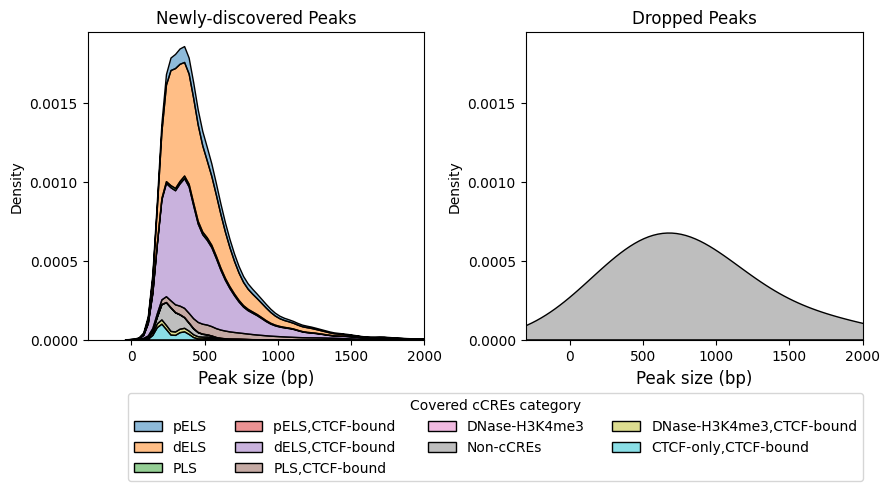

In [33]:
cCRE_newly_discovered_peaks['covered_cCREs_category'] = cCRE_newly_discovered_peaks['encode_label'] 
cCRE_newly_discovered_peaks.loc[cCRE_newly_discovered_peaks['encode_label'] == '.', 'covered_cCREs_category'] = 'Non-cCREs'

cCRE_lost_peaks['covered_cCREs_category'] = cCRE_lost_peaks['encode_label']
cCRE_lost_peaks.loc[cCRE_lost_peaks['encode_label'] == '.', 'covered_cCREs_category'] = 'Non-cCREs'



hue_color = ['pELS', 'dELS', 'PLS', 
             'pELS,CTCF-bound ',  'dELS,CTCF-bound', "PLS,CTCF-bound", 
             'DNase-H3K4me3', 'Non-cCREs',  "DNase-H3K4me3,CTCF-bound", 'CTCF-only,CTCF-bound',]
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

g0 = sns.kdeplot(data=cCRE_newly_discovered_peaks, x='peak_size', hue='covered_cCREs_category', fill=True, ax=ax[0], 
            common_norm=True, alpha=0.5, hue_order=hue_color, multiple='stack')
g1 = sns.kdeplot(data=cCRE_lost_peaks, x='peak_size', hue='covered_cCREs_category', fill=True, ax=ax[1], 
            common_norm=True, alpha=0.5, hue_order=hue_color, multiple='stack')

ax[0].set_xlabel('Peak size (bp)', fontsize=12)
ax[0].set_title('Newly-discovered Peaks', fontsize=12)
ax[1].set_xlabel('Peak size (bp)', fontsize=12)
ax[1].set_title('Dropped Peaks', fontsize=12)

ax[0].set_xlim(-300, 2000)
ax[1].set_xlim(-300, 2000)
ax[0].set_xticks(np.arange(0, 2001, 500))
ax[1].set_xticks(np.arange(0, 2001, 500))
ax[0].set_ylim(0, ax[0].get_ylim()[1])
ax[1].set_ylim(0, ax[0].get_ylim()[1])
ax[0].set_yticks(np.arange(0, ax[0].get_ylim()[1], 0.0005))
ax[1].set_yticks(np.arange(0, ax[0].get_ylim()[1] , 0.0005))


ax[1].legend_.remove()
sns.move_legend(ax[0], "upper left", bbox_to_anchor=(0.1, -.15), title='Covered cCREs category', fontsize=10, ncol=4)


fig.subplots_adjust(wspace=0.3)

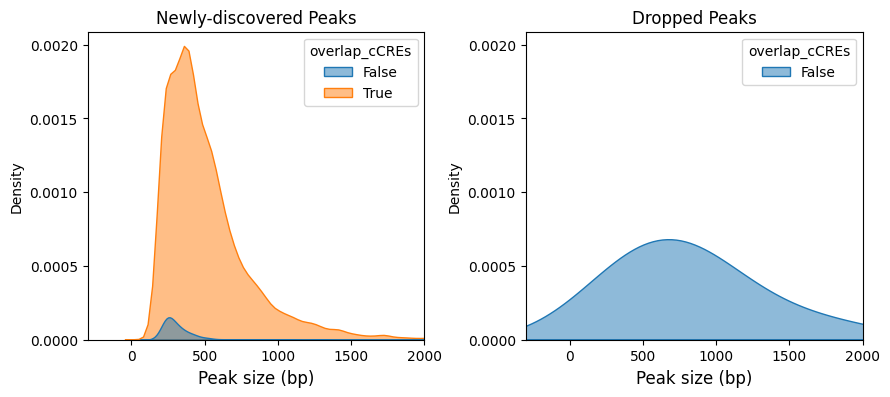

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

g0 = sns.kdeplot(data=cCRE_newly_discovered_peaks, x='peak_size', hue='overlap_cCREs', fill=True, ax=ax[0], 
            common_norm=True, alpha=0.5, color=['green', 'grey'])
g1 = sns.kdeplot(data=cCRE_lost_peaks, x='peak_size', hue='overlap_cCREs', fill=True, ax=ax[1], 
            common_norm=True, alpha=0.5, color=['green', 'grey'])

ax[0].set_xlabel('Peak size (bp)', fontsize=12)
ax[0].set_title('Newly-discovered Peaks', fontsize=12)
ax[1].set_xlabel('Peak size (bp)', fontsize=12)
ax[1].set_title('Dropped Peaks', fontsize=12)

ax[0].set_xlim(-300, 2000)
ax[1].set_xlim(-300, 2000)
ax[0].set_xticks(np.arange(0, 2001, 500))
ax[1].set_xticks(np.arange(0, 2001, 500))
ax[0].set_ylim(0, ax[0].get_ylim()[1])
ax[1].set_ylim(0, ax[0].get_ylim()[1])
ax[0].set_yticks(np.arange(0, ax[0].get_ylim()[1], 0.0005))
ax[1].set_yticks(np.arange(0, ax[0].get_ylim()[1] , 0.0005))


fig.subplots_adjust(wspace=0.3)

# Not necessary useful 

/tmp/ipykernel_213178/3597221937.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].x_ticklabels, rotation=45, ha='right', fontsize=10)
/tmp/ipykernel_213178/3597221937.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].x_ticklabels, rotation=45, ha='right', fontsize=10)


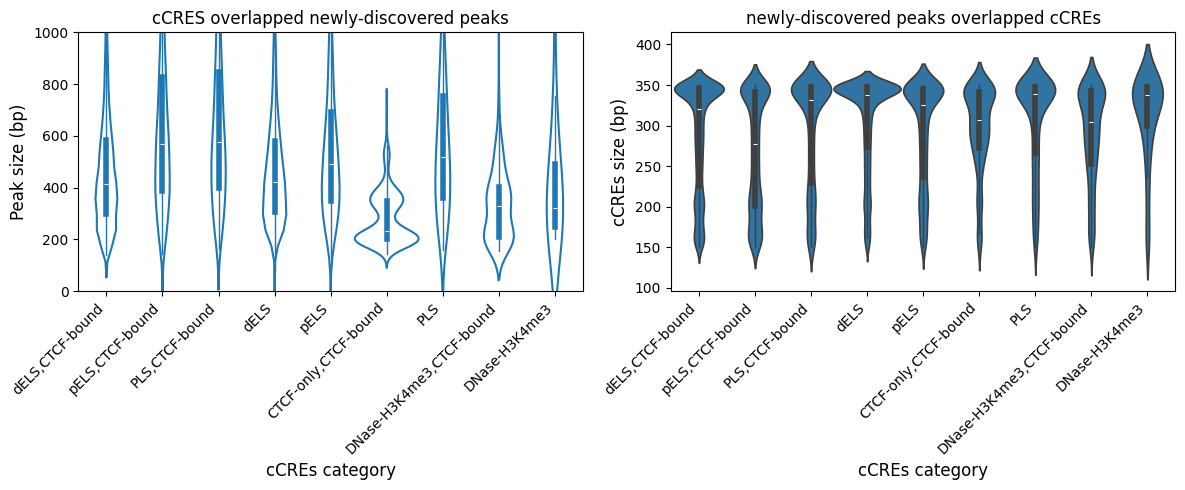

In [35]:


fig, ax = plt.subplots( 1, 2, figsize=( 12, 5))


sns.violinplot(data=cCRE_newly_discovered_peaks.loc[cCRE_newly_discovered_peaks['overlap_bp'] > 0],
            y='peak_size', x='encode_label',  width=1.2,  inner_kws=dict(box_width=4, whis_width=1),
            fill=False, gap=.05, ax=ax[0])

ax[0].x_ticklabels = ax[0].get_xticklabels()
ax[0].set_xticklabels(ax[0].x_ticklabels, rotation=45, ha='right', fontsize=10)
ax[0].set_title('cCRES overlapped newly-discovered peaks', fontsize=12)
ax[0].set_xlabel('cCREs category', fontsize=12)
ax[0].set_ylabel('Peak size (bp)', fontsize=12)
ax[0].set_ylim(0, 1000)
# sns.move_legend(ax[0], "upper left", bbox_to_anchor=(1.03, 1))

sns.violinplot(data=cCRE_newly_discovered_peaks.loc[cCRE_newly_discovered_peaks['overlap_bp'] > 0], 
            y='cCREs_size', x='encode_label', width=1.2,  inner_kws=dict(box_width=4, whis_width=1),
            ax=ax[1])


ax[1].x_ticklabels = ax[1].get_xticklabels()
ax[1].set_xticklabels(ax[1].x_ticklabels, rotation=45, ha='right', fontsize=10)
ax[1].set_title('newly-discovered peaks overlapped cCREs', fontsize=12)
ax[1].set_xlabel('cCREs category', fontsize=12)
ax[1].set_ylabel('cCREs size (bp)', fontsize=12)


plt.tight_layout()


/tmp/ipykernel_213178/3010609903.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].x_ticklabels, rotation=45, ha='right', fontsize=10)
/tmp/ipykernel_213178/3010609903.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].x_ticklabels, rotation=45, ha='right', fontsize=10)


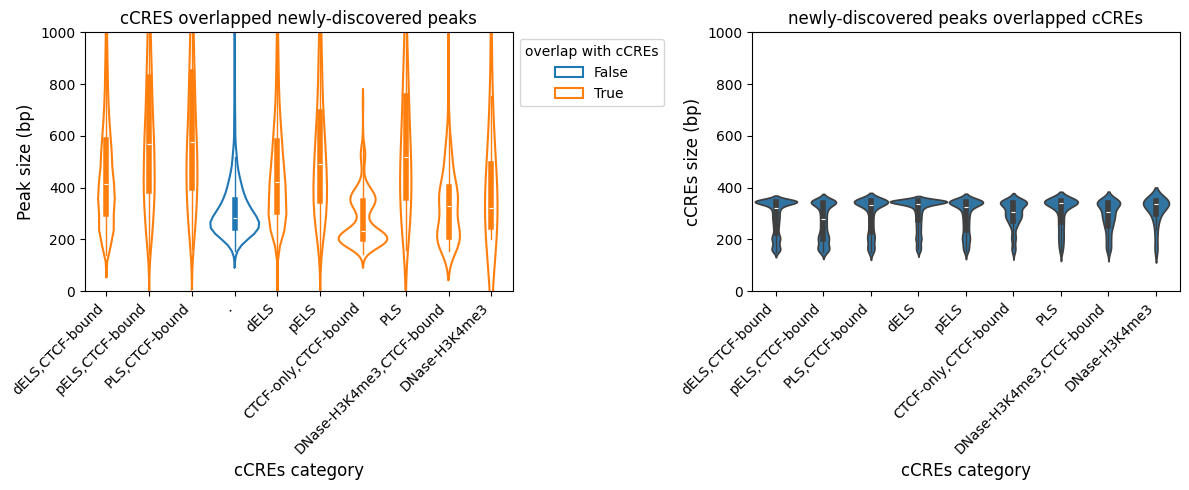

In [36]:

fig, ax = plt.subplots( 1, 2, figsize=( 12, 5))


sns.violinplot(data=cCRE_newly_discovered_peaks,
            y='peak_size', x='encode_label', hue='overlap_cCREs', width=1.2,  inner_kws=dict(box_width=4, whis_width=1),
            fill=False, gap=.05, ax=ax[0])

ax[0].x_ticklabels = ax[0].get_xticklabels()
ax[0].set_xticklabels(ax[0].x_ticklabels, rotation=45, ha='right', fontsize=10)
ax[0].set_title('cCRES overlapped newly-discovered peaks', fontsize=12)
ax[0].set_xlabel('cCREs category', fontsize=12)
ax[0].set_ylabel('Peak size (bp)', fontsize=12)
ax[0].legend(title='overlap with cCREs', loc='upper right', fontsize=10)
sns.move_legend(ax[0], "upper left", bbox_to_anchor=(1, 1))

sns.violinplot(data=cCRE_newly_discovered_peaks.loc[cCRE_newly_discovered_peaks['overlap_bp'] > 0], 
            y='cCREs_size', x='encode_label', width=1.2,  inner_kws=dict(box_width=4, whis_width=1),
            ax=ax[1])


ax[1].x_ticklabels = ax[1].get_xticklabels()
ax[1].set_xticklabels(ax[1].x_ticklabels, rotation=45, ha='right', fontsize=10)
ax[1].set_title('newly-discovered peaks overlapped cCREs', fontsize=12)
ax[1].set_xlabel('cCREs category', fontsize=12)
ax[1].set_ylabel('cCREs size (bp)', fontsize=12)


ax[0].set_ylim(0, 1000)
ax[1].set_ylim(0, 1000)

plt.tight_layout()